In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.integrate import solve_ivp
from numpy.linalg import svd
import time

# ================== CONFIGURATIONS ======================
np.random.seed(42)
param_range_reservoir = [(9, 11), (2.6, 2.8), (27, 29)]
param_range_R = [(1, 30)]
t_initial, t_final = 0, 1
num_eval_points = 500
input_csv = "input_data.csv"
output_csv = "output_data.csv"

# eps_values = [0.9, 0.5, 0.1, 0.05, 1e-2, 1e-4, 1e-6, 1e-10]
eps_values = [0.5]

# ================= LOAD DATA ======================
num_train_samples = 1000
input_data = pd.read_csv(input_csv).iloc[:, 1:num_train_samples+1].values
output_data = pd.read_csv(output_csv).iloc[:, 1:num_train_samples+1].values

D, M, P = input_data.shape[1], input_data.shape[0], output_data.shape[0]

scaler_input = StandardScaler()
input_data_norm = scaler_input.fit_transform(input_data.T).T

scaler_output = StandardScaler()
output_data_norm = scaler_output.fit_transform(output_data.T).T

# ================= LORENZ SYSTEM ======================
def lorenz_system(t, X, params):
    X = X.reshape(len(params), 3)
    dxdt = (1 / params[:, 3]) * params[:, 0] * (X[:, 1] - X[:, 0])
    dydt = (1 / params[:, 3]) * (X[:, 0] * (params[:, 1] - X[:, 2]) - X[:, 1])
    dzdt = (1 / params[:, 3]) * (X[:, 0] * X[:, 1] - params[:, 2] * X[:, 2])
    return np.stack([dxdt, dydt, dzdt], axis=1).flatten()

# ================= ENTROPY ======================
def compute_topological_entropy(trajectory, eps_values):
    entropy_estimates = {}
    for eps in eps_values:
        unique_orbits = set()
        for point in trajectory:
            rounded_point = tuple(np.round(point / eps))
            unique_orbits.add(rounded_point)
        N_eps = len(unique_orbits)
        entropy_estimates[eps] = np.log(N_eps + 1e-12) / len(trajectory)
    return entropy_estimates

# ================= LINEAR METRICS ======================
def effective_rank(matrix):
    U, s, _ = svd(matrix, full_matrices=False)
    p = s / (np.sum(s) + 1e-12)
    return np.exp(-np.sum(p * np.log(p + 1e-12)))

def mean_abs_corr(matrix):
    corr = np.corrcoef(matrix)
    upper = corr[np.triu_indices_from(corr, k=1)]
    return np.nanmean(np.abs(upper))

def covariance_trace(matrix):
    C = np.cov(matrix)
    return np.trace(C)

def covariance_rank(matrix):
    return np.linalg.matrix_rank(matrix @ matrix.T)

# ================= LOOP OVER N ======================
N_values = range(10, 310, 10)

entropy_results = {eps: [] for eps in eps_values}
rank_results = []
corr_results = []
covtrace_results = []
covrank_results = []

start_time = time.time()

for N in N_values:
    print(f"Running for N = {N}...")

    reservoir_params = np.array([
        [np.random.uniform(low, high) for low, high in param_range_reservoir] + [np.random.uniform(1, 10)]
        for _ in range(N)
    ])

    R = np.random.uniform(param_range_R[0][0], param_range_R[0][1], size=(3 * N, M))

    entropy_sums = {eps: 0 for eps in eps_values}
    phi_all = []   # store final states for linear metrics

    for i in range(D):

        input_vector = np.dot(R, input_data_norm[:, i]).flatten()

        t_eval = np.linspace(t_initial, t_final, num_eval_points)

        sol = solve_ivp(
            lorenz_system,
            (t_initial, t_final),
            input_vector,
            t_eval=t_eval,
            args=(reservoir_params,),
            method='RK45',
            rtol=1e-6,
            atol=1e-9
        )

        trajectory = sol.y.T

        # ===== entropy =====
        entropy_values = compute_topological_entropy(trajectory, eps_values)
        for eps in eps_values:
            entropy_sums[eps] += entropy_values[eps]

        # ===== store final state =====
        phi_all.append(sol.y[:, -1])

    # ===== average entropy =====
    for eps in eps_values:
        entropy_results[eps].append(entropy_sums[eps] / D)

    # ===== build reservoir matrix =====
    phi_matrix = np.array(phi_all).T   # shape (3N, D)

    # ===== linear metrics =====
    rank_results.append(effective_rank(phi_matrix))
    corr_results.append(mean_abs_corr(phi_matrix))
    covtrace_results.append(covariance_trace(phi_matrix))
    covrank_results.append(covariance_rank(phi_matrix))   # <-- ADD THIS

# ================= SAVE RESULTS ======================
results_df = pd.DataFrame({
    "N": list(N_values),
    "effective_rank": rank_results,
    "mean_abs_correlation": corr_results,
    "cov_trace": covtrace_results,
    "covariance_rank": covrank_results   # <-- ADD THIS
})

for eps in eps_values:
    results_df[f"entropy_eps_{eps}"] = entropy_results[eps]

output_csv_file = "entropy_linear_metrics_vs_N.csv"
results_df.to_csv(output_csv_file, index=False)

print(f"Results saved to {output_csv_file}")



/Users/halders2/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Running for N = 10...


/var/folders/rp/3svz678x3dlfx98xp15q82b12rg7gw/T/ipykernel_58030/2092651390.py:70: RuntimeWarning: divide by zero encountered in matmul
  return np.linalg.matrix_rank(matrix @ matrix.T)
/var/folders/rp/3svz678x3dlfx98xp15q82b12rg7gw/T/ipykernel_58030/2092651390.py:70: RuntimeWarning: overflow encountered in matmul
  return np.linalg.matrix_rank(matrix @ matrix.T)
/var/folders/rp/3svz678x3dlfx98xp15q82b12rg7gw/T/ipykernel_58030/2092651390.py:70: RuntimeWarning: invalid value encountered in matmul
  return np.linalg.matrix_rank(matrix @ matrix.T)


Running for N = 20...
Running for N = 30...
Running for N = 40...
Running for N = 50...
Running for N = 60...
Running for N = 70...
Running for N = 80...
Running for N = 90...
Running for N = 100...
Running for N = 110...
Running for N = 120...
Running for N = 130...
Running for N = 140...
Running for N = 150...
Running for N = 160...
Running for N = 170...
Running for N = 180...
Running for N = 190...
Running for N = 200...
Running for N = 210...
Running for N = 220...
Running for N = 230...
Running for N = 240...
Running for N = 250...
Running for N = 260...
Running for N = 270...
Running for N = 280...
Running for N = 290...
Running for N = 300...
Results saved to entropy_linear_metrics_vs_N.csv


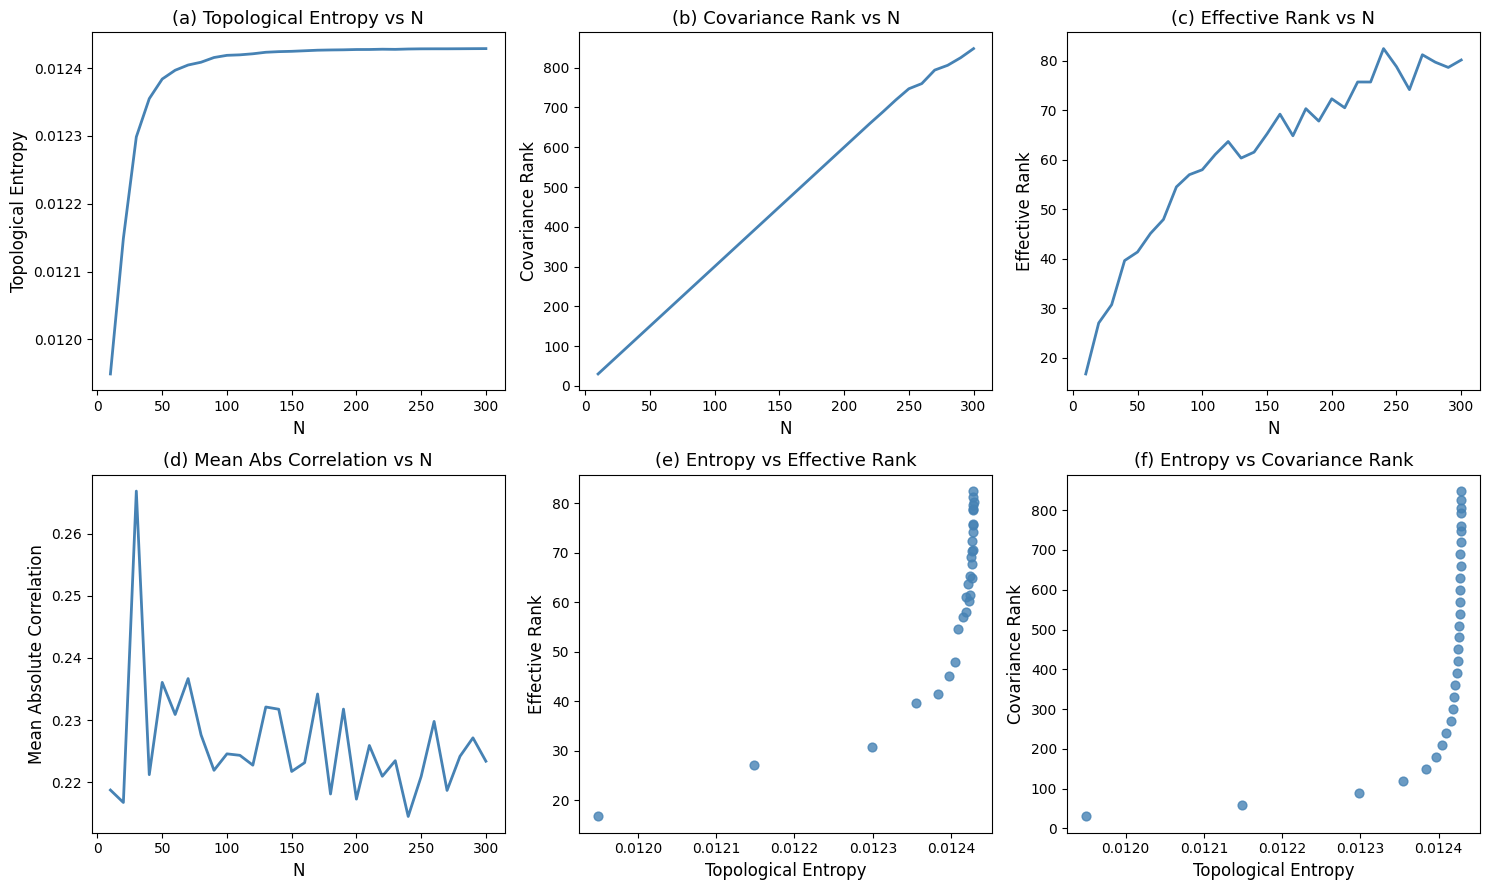

In [8]:
# Plotting

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Panel (a): Entropy vs N
axes[0, 0].plot(N_values, entropy_results[eps_main], color='steelblue', linewidth=2)
axes[0, 0].set_xlabel("N", fontsize=12)
axes[0, 0].set_ylabel("Topological Entropy", fontsize=12)
axes[0, 0].set_title("(a) Topological Entropy vs N", fontsize=13)

# Panel (b): Covariance Rank vs N
axes[0, 1].plot(N_values, covrank_results, color='steelblue', linewidth=2)
axes[0, 1].set_xlabel("N", fontsize=12)
axes[0, 1].set_ylabel("Covariance Rank", fontsize=12)
axes[0, 1].set_title("(b) Covariance Rank vs N", fontsize=13)

# Panel (c): Effective Rank vs N
axes[0, 2].plot(N_values, rank_results, color='steelblue', linewidth=2)
axes[0, 2].set_xlabel("N", fontsize=12)
axes[0, 2].set_ylabel("Effective Rank", fontsize=12)
axes[0, 2].set_title("(c) Effective Rank vs N", fontsize=13)

# Panel (d): Mean Abs Correlation vs N
axes[1, 0].plot(N_values, corr_results, color='steelblue', linewidth=2)
axes[1, 0].set_xlabel("N", fontsize=12)
axes[1, 0].set_ylabel("Mean Absolute Correlation", fontsize=12)
axes[1, 0].set_title("(d) Mean Abs Correlation vs N", fontsize=13)

# Panel (e): Entropy vs Effective Rank scatter
axes[1, 1].scatter(entropy_results[eps_main], rank_results,
                   color='steelblue', s=40, alpha=0.8)
axes[1, 1].set_xlabel("Topological Entropy", fontsize=12)
axes[1, 1].set_ylabel("Effective Rank", fontsize=12)
axes[1, 1].set_title("(e) Entropy vs Effective Rank", fontsize=13)

# Panel (f): Entropy vs Covariance Rank scatter
axes[1, 2].scatter(entropy_results[eps_main], covrank_results,
                   color='steelblue', s=40, alpha=0.8)
axes[1, 2].set_xlabel("Topological Entropy", fontsize=12)
axes[1, 2].set_ylabel("Covariance Rank", fontsize=12)
axes[1, 2].set_title("(f) Entropy vs Covariance Rank", fontsize=13)

plt.tight_layout()
plt.savefig("Figure_Y_entropy_vs_linear_metrics.pdf", dpi=300, bbox_inches='tight')
plt.savefig("Figure_Y_entropy_vs_linear_metrics.png", dpi=300, bbox_inches='tight')
plt.show()